In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [ ]:
raw_data = fetch_california_housing(as_frame=True)
df= raw_data.frame

df_sample = df.sample(n=20640, random_state=42).sort_values(by='MedInc')

x = df_sample['MedInc'].values
y = df_sample['MedHouseVal'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Dataset loaded, Training shapes: X: {X_train.shape}, y: {y_train.shape}")
df_sample[['MedInc','MedHouseVal']].head()

Dataset loaded, Training shapes: X: (16512,), y: (16512, 1)


,MedInc,MedHouseVal
7125,0.4999,1.625
13999,0.4999,0.550
3249,0.4999,1.000
5213,0.4999,0.906
73,0.4999,0.675


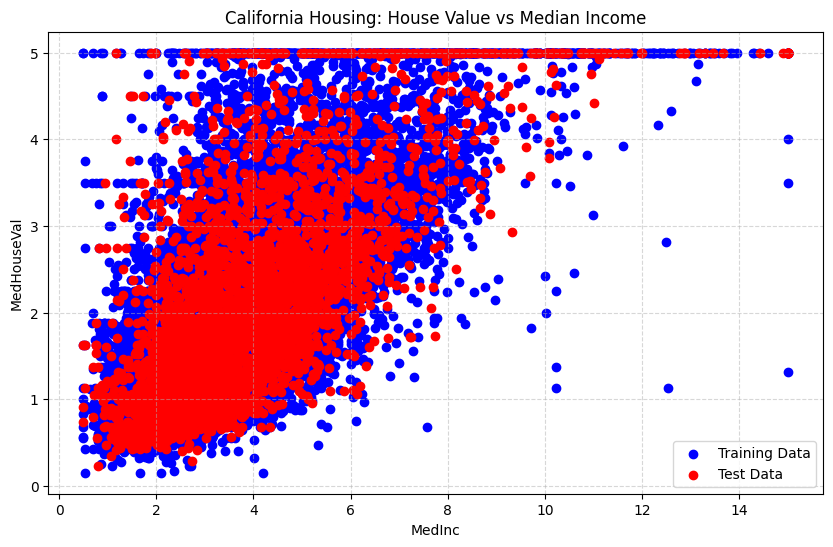

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.title('California Housing: House Value vs Median Income')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.legend()
plt.grid(True, linestyle='--',alpha = 0.5)
plt.show()

In [ ]:
X_train_bias = np.c_[np.ones(len(X_train)), X_train]
X_test_bias = np.c_[np.ones(len(X_test)), X_test]
#

theta_best = np.linalg.inv(X_train_bias.T.dot(X_train_bias)).dot(X_train_bias.T).dot(y_train)

intercept, slope = theta_best[0][0], theta_best[1][0]
print(f"Calculated Intercept (w0): {intercept:.4f}")
print(f"Calculated Slope (w1): {slope:.4f}")

y_pred_ols = X_test_bias.dot(theta_best)
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)
print(f"Mean Squared Error (MSE): {mse_ols:.4f}")
print(f"R-squared (R2): {r2_ols:.4f}")

Calculated Intercept (w0): 0.4500
Calculated Slope (w1): 0.4180
Mean Squared Error (MSE): 0.6957
R-squared (R2): 0.4764


In [ ]:
def get_polynomial_features(x_matrix, degree = 3):
  return np.hstack([x_matrix**i for i in range(1, degree+1)])

# Reshape X_train and X_test to 2D arrays (column vectors)
X_train_reshaped = X_train.reshape(-1, 1)
X_test_reshaped = X_test.reshape(-1, 1)

X_train_poly = get_polynomial_features(X_train_reshaped, degree=3)
X_test_poly = get_polynomial_features(X_test_reshaped, degree=3)

theta_best_poly = np.linalg.inv(X_train_poly.T.dot(X_train_poly)).dot(X_train_poly.T).dot(y_train)

X_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1,1)
X_line_poly = get_polynomial_features(X_line, degree=3)
y_line_poly = X_line_poly.dot(theta_best_poly)

y_pred_poly = X_test_poly.dot(theta_best_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print("Polynomial Regression Results:")
print(f"Mean Squared Error (MSE): {mse_poly:.4f}")
print(f"R-squared (R2): {r2_poly:.4f}")

Polynomial Regression Results:
Mean Squared Error (MSE): 0.6956
R-squared (R2): 0.4764


Now, let's explore **Lasso** and **Ridge Regression**, which are regularized linear models designed to prevent overfitting by adding a penalty to the loss function. We'll use `X_train_reshaped` and `X_test_reshaped` as input for these models, as they are single-feature linear models.

In [ ]:
# Lasso Regression
lasso_model = Lasso(alpha=0.01, random_state=42) # alpha is the regularization strength
lasso_model.fit(X_train_reshaped, y_train)

y_pred_lasso = lasso_model.predict(X_test_reshaped).reshape(-1, 1)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results:")
print(f"Mean Squared Error (MSE): {mse_lasso:.4f}")
print(f"R-squared (R2): {r2_lasso:.4f}")
print(f"Lasso Intercept: {lasso_model.intercept_[0]:.4f}")
print(f"Lasso Coefficient: {lasso_model.coef_[0]:.4f}")

Lasso Regression Results:
Mean Squared Error (MSE): 0.6957
R-squared (R2): 0.4763
Lasso Intercept: 0.4607
Lasso Coefficient: 0.4152


In [ ]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0, random_state=42) # alpha is the regularization strength
ridge_model.fit(X_train_reshaped, y_train)

y_pred_ridge = ridge_model.predict(X_test_reshaped).reshape(-1, 1)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression Results:")
print(f"Mean Squared Error (MSE): {mse_ridge:.4f}")
print(f"R-squared (R2): {r2_ridge:.4f}")
print(f"Ridge Intercept: {ridge_model.intercept_[0]:.4f}")
print(f"Ridge Coefficient: {ridge_model.coef_[0]:.4f}")


Ridge Regression Results:
Mean Squared Error (MSE): 0.6957
R-squared (R2): 0.4764
Ridge Intercept: 0.4500
Ridge Coefficient: 0.4180


Let's visualize all four models together to compare their fits to the data.

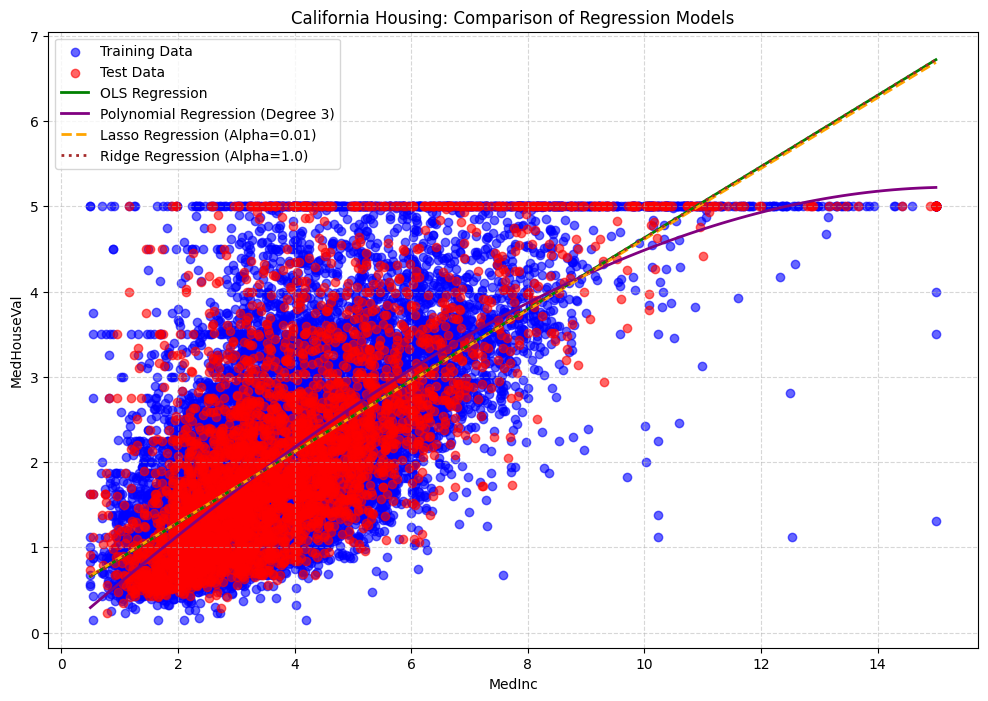

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
plt.scatter(X_test, y_test, color='red', label='Test Data', alpha=0.6)

# OLS Regression Line
plt.plot(X_line, intercept + slope * X_line, color='green', label='OLS Regression', linewidth=2)

# Polynomial Regression Line
plt.plot(X_line, y_line_poly, color='purple', label='Polynomial Regression (Degree 3)', linewidth=2)

# Lasso Regression Line
y_line_lasso = lasso_model.predict(X_line).reshape(-1, 1)
plt.plot(X_line, y_line_lasso, color='orange', label='Lasso Regression (Alpha=0.01)', linewidth=2, linestyle='--')

# Ridge Regression Line
y_line_ridge = ridge_model.predict(X_line).reshape(-1, 1)
plt.plot(X_line, y_line_ridge, color='brown', label='Ridge Regression (Alpha=1.0)', linewidth=2, linestyle=':')

plt.title('California Housing: Comparison of Regression Models')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

This plot provides a visual comparison of all four regression models. We can observe how each model attempts to capture the relationship between `MedInc` and `MedHouseVal`. The OLS and Polynomial Regression provide a baseline, while Lasso and Ridge apply regularization, which can sometimes lead to simpler models and potentially better generalization on unseen data, depending on the data characteristics and hyperparameter tuning. It's worth noting that for this specific dataset and the chosen regularization strengths, the linear models (OLS, Lasso, Ridge) might appear quite similar visually, while the polynomial model shows a curve.